In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [13]:
path = "Demirjian v. Kohler Data (AI Analyses - for Dr. Siddharth).xlsx"
male = pd.read_excel(path, sheet_name="Male Data", engine="openpyxl")
male_test = pd.read_excel(path, sheet_name="Male Test Data", engine="openpyxl")
female = pd.read_excel(path, sheet_name="Female Data", engine="openpyxl")
female_test = pd.read_excel(path, sheet_name="Female Test Data", engine="openpyxl")
print(male.head())

  Sl. No. Sex  Completed Age  Total  31  32  33  34  35  36  37  38  18  28  \
0      21   M             10  71.10   9   8   7   7   7   9   6   4   3   4   
1      54   M             10  73.43   9   9   7   7   7   9   6   2   0   0   
2     226   M             10  75.04   9   9   7   7   7   9   6   4   2   2   
3      19   M             11  64.23   8   8   7   7   6   9   6   3   1   2   
4     122   M             11  83.83   9   9   8   8   8   9   8   4   3   3   

   38.1  48  
0     3   3  
1     0   0  
2     2   2  
3     1   1  
4     3   3  


In [14]:
def plot_results(y_test, y_pred):
    """
    Plots the SVR model's predictions against the actual data.
    Args:
        y_test (np.array): The testing target data.
        y_pred (np.array): The predicted target values from the model.
    """
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(8, 8))
    # Plot the predicted values against the actual values
    plt.scatter(y_test, y_pred, c='blue', s=50, alpha=0.7, label='Predicted vs. Actual')
    # Plot a perfect prediction line (y=x) for comparison
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], c='red', linestyle='--', linewidth=2, label='Perfect Prediction')
    # Add labels and a title to the plot
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('SVR Model: Predicted vs. Actual Values')
    plt.legend()
    plt.tight_layout()
    plt.show()

Best Parameters found by GridSearchCV:
{'C': 1, 'epsilon': 0.01, 'kernel': 'poly'}
SVR Model Evaluation Metrics:
------------------------------
Mean Squared Error(MSE):2.19013
Root Mean Squared Error (RMSE): 1.47991
R-squared ($R^2$): 0.70717


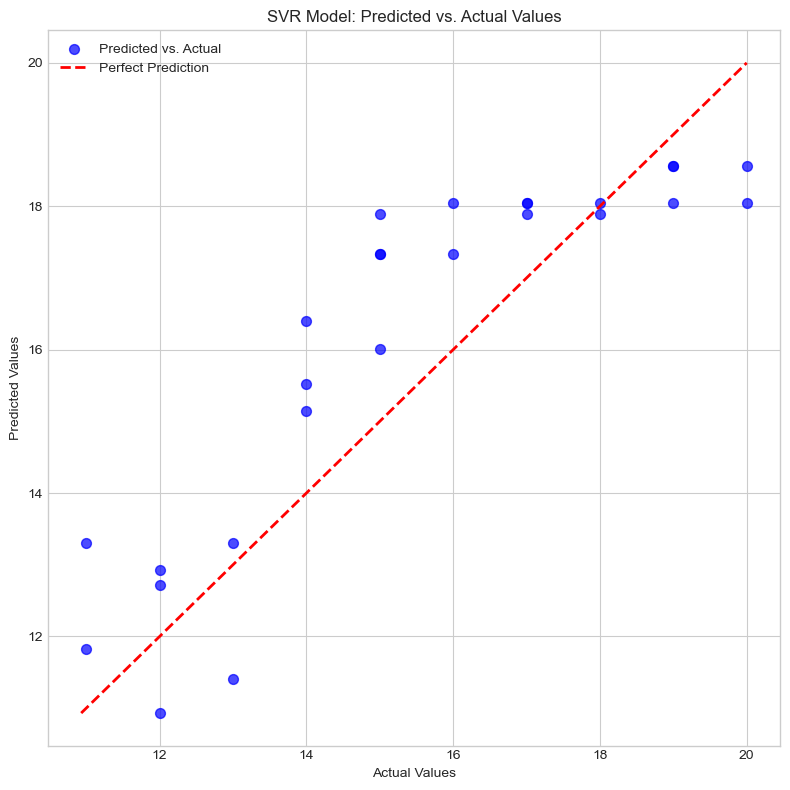

In [18]:
x_train=male["Total"]
y_train=male["Completed Age"]
x_test=male_test["Total"]
y_test=male_test["Completed Age"]
# svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)
svr_model= SVR()
param_grid = {
    'kernel': ['rbf', 'linear', 'poly'],
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 1],
}
grid_search=GridSearchCV(svr_model,param_grid,cv=5,scoring='r2')
grid_search.fit(x_train.to_frame(),y_train)
best_svr_model=grid_search.best_estimator_
best_params=grid_search.best_params_
print("Best Parameters found by GridSearchCV:")
print(best_params)
y_pred=best_svr_model.predict(x_test.to_frame())
mse=mean_squared_error(y_test, y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test, y_pred)
print("SVR Model Evaluation Metrics:")
print("-"*30)
print(f"Mean Squared Error(MSE):{mse:.5f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.5f}")
print(f"R-squared ($R^2$): {r2:.5f}")
plot_results(y_test, y_pred)

Best Parameters found by GridSearchCV:
{'C': 0.1, 'epsilon': 0.01, 'kernel': 'linear'}
SVR Model Evaluation Metrics:
------------------------------
Mean Squared Error (MSE): 1.42472
Root Mean Squared Error (RMSE): 1.19362
R-squared ($R^2$): 0.80951


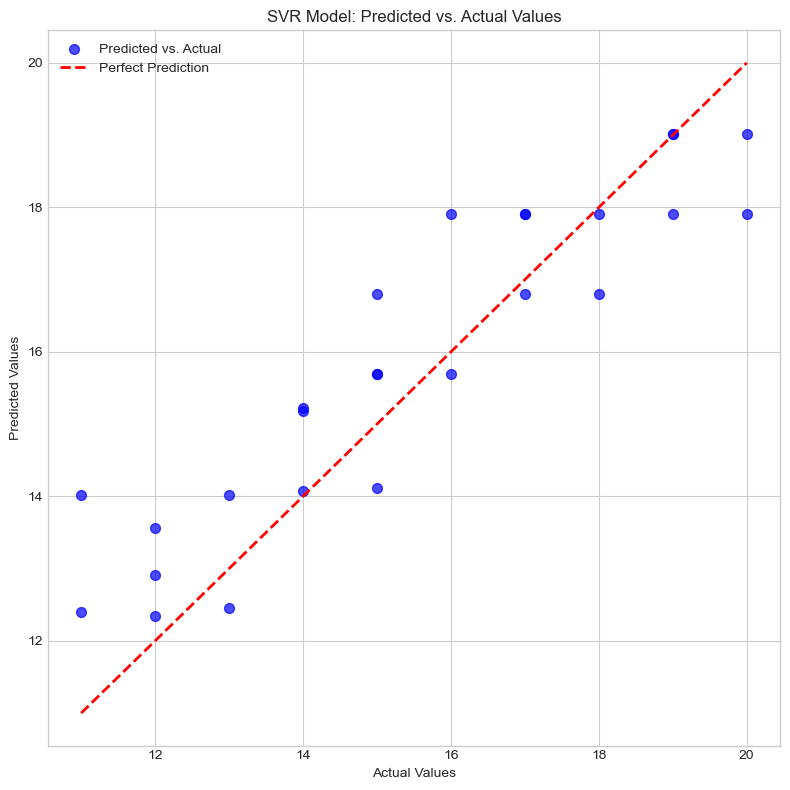

In [20]:
x_train=male[[31, 32, 33, 34, 35, 36, 37, 38]]
y_train=male["Completed Age"]
x_test=male_test[[31, 32, 33, 34, 35, 36, 37, 38]]
y_test=male_test["Completed Age"]
# svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)
svr_model=SVR()
param_grid={
'kernel': ['rbf', 'linear', 'poly'],
'C': [0.1, 1, 10, 100],
'epsilon': [0.01, 0.1, 1]
}
grid_search=GridSearchCV(svr_model,param_grid,cv=5,scoring='r2')
grid_search.fit(x_train, y_train)
best_svr_model = grid_search.best_estimator_
best_params = grid_search.best_params_
print("Best Parameters found by GridSearchCV:")
print(best_params)
y_pred = best_svr_model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("SVR Model Evaluation Metrics:")
print("-" * 30)
print(f"Mean Squared Error (MSE): {mse:.5f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.5f}")
print(f"R-squared ($R^2$): {r2:.5f}")
plot_results(y_test,y_pred)

Best Parameters found by GridSearchCV:
{'C': 0.1, 'epsilon': 0.1, 'kernel': 'linear'}
SVR Model Evaluation Metrics:
------------------------------
Mean Squared Error (MSE): 1.63125
Root Mean Squared Error (RMSE): 1.27720
R-squared ($R^2$): 0.78190


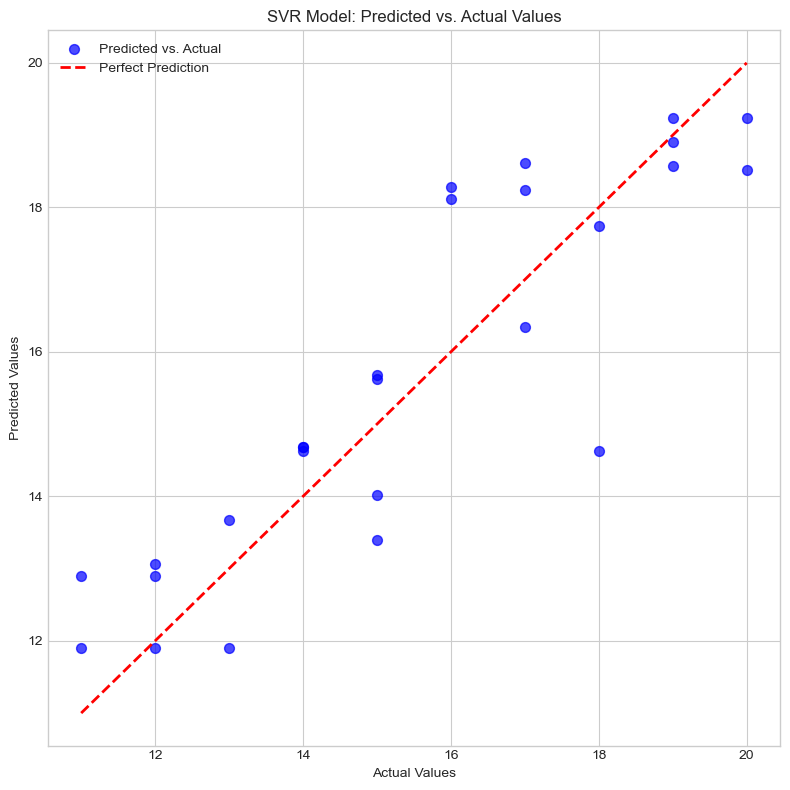

In [21]:
x_train = male[[18, 28, 38, 48]]
y_train = male["Completed Age"]
x_test = male_test[[18, 28, 38, 48]]
y_test = male_test["Completed Age"]
# svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)
svr_model = SVR()
param_grid = {
    'kernel': ['rbf', 'linear', 'poly'],
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 1]
}
grid_search = GridSearchCV(svr_model, param_grid, cv=5, scoring='r2')
grid_search.fit(x_train, y_train)
best_svr_model = grid_search.best_estimator_
best_params = grid_search.best_params_
print("Best Parameters found by GridSearchCV:")
print(best_params)
y_pred = best_svr_model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("SVR Model Evaluation Metrics:")
print("-" * 30)
print(f"Mean Squared Error (MSE): {mse:.5f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.5f}")
print(f"R-squared ($R^2$): {r2:.5f}")
plot_results(y_test, y_pred)

Best Parameters found by GridSearchCV:
{'C': 100, 'epsilon': 0.01, 'kernel': 'rbf'}
SVR Model Evaluation Metrics:
------------------------------
Mean Squared Error (MSE): 2.38273
Root Mean Squared Error (RMSE): 1.54361
R-squared ($R^2$): 0.68079


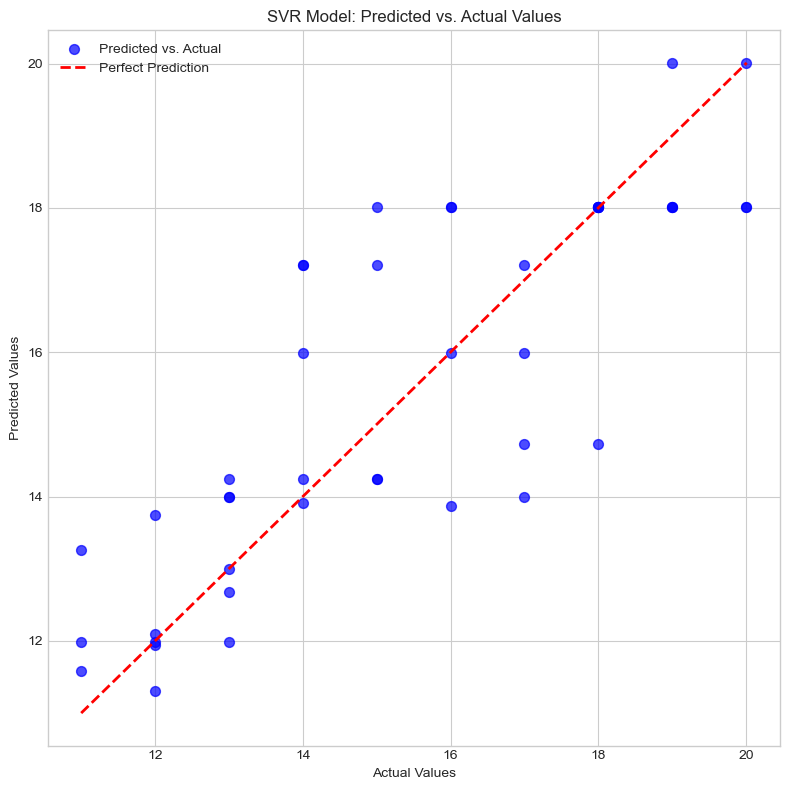

In [22]:
x_train = female["Total Score"]
y_train = female["Completed Age"]
x_test = female_test["Total Score"]
y_test = female_test["Completed Age"]
# svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)
svr_model = SVR()
param_grid = {
'kernel': ['rbf', 'linear', 'poly'],
'C': [0.1, 1, 10, 100],
'epsilon': [0.01, 0.1, 1]
}
grid_search = GridSearchCV(svr_model, param_grid, cv=5, scoring='r2')
grid_search.fit(x_train.to_frame(), y_train)
best_svr_model = grid_search.best_estimator_
best_params = grid_search.best_params_
print("Best Parameters found by GridSearchCV:")
print(best_params)
y_pred = best_svr_model.predict(x_test.to_frame())
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("SVR Model Evaluation Metrics:")
print("-" * 30)
print(f"Mean Squared Error (MSE): {mse:.5f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.5f}")
print(f"R-squared ($R^2$): {r2:.5f}")
plot_results(y_test, y_pred)

Best Parameters found by GridSearchCV:
{'C': 0.1, 'epsilon': 0.1, 'kernel': 'linear'}
SVR Model Evaluation Metrics:
------------------------------
Mean Squared Error (MSE): 2.32451
Root Mean Squared Error (RMSE): 1.52464
R-squared ($R^2$): 0.68859


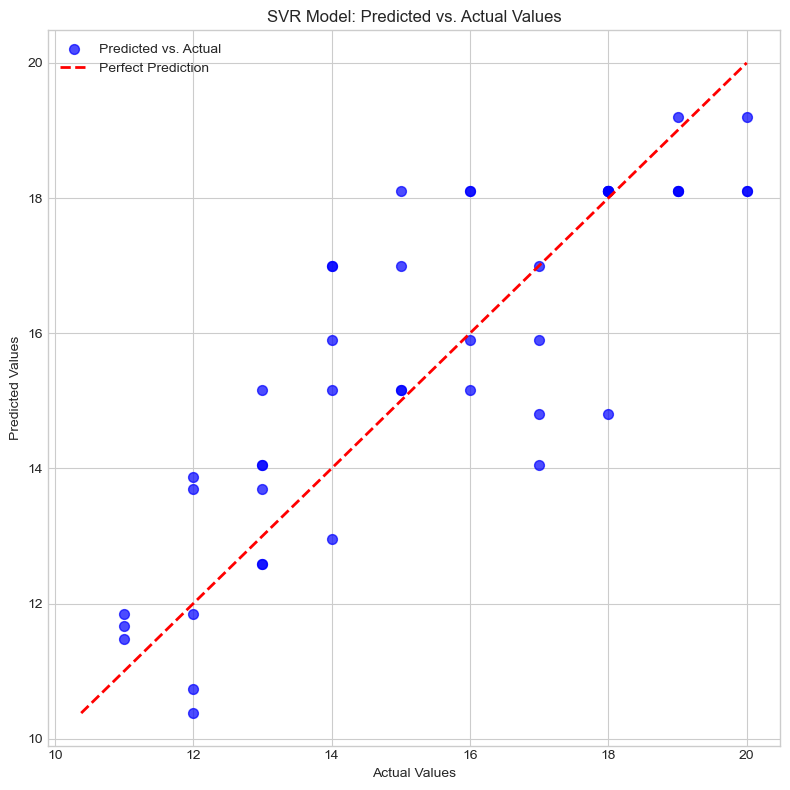

In [23]:
x_train = female[[31, 32, 33, 34, 35, 36, 37, 38]]
y_train = female["Completed Age"]
x_test = female_test[[31, 32, 33, 34, 35, 36, 37, 38]]
y_test = female_test["Completed Age"]
# svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)
svr_model = SVR()
param_grid = {
'kernel': ['rbf', 'linear', 'poly'],
'C': [0.1, 1, 10, 100],
'epsilon': [0.01, 0.1, 1]
}
grid_search = GridSearchCV(svr_model, param_grid, cv=5, scoring='r2')
grid_search.fit(x_train, y_train)
best_svr_model = grid_search.best_estimator_
best_params = grid_search.best_params_
print("Best Parameters found by GridSearchCV:")
print(best_params)
y_pred = best_svr_model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("SVR Model Evaluation Metrics:")
print("-" * 30)
print(f"Mean Squared Error (MSE): {mse:.5f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.5f}")
print(f"R-squared ($R^2$): {r2:.5f}")
plot_results(y_test, y_pred)

Best Parameters found by GridSearchCV:
{'C': 0.1, 'epsilon': 0.1, 'kernel': 'linear'}
SVR Model Evaluation Metrics:
------------------------------
Mean Squared Error (MSE): 3.07439
Root Mean Squared Error (RMSE): 1.75339
R-squared ($R^2$): 0.58812


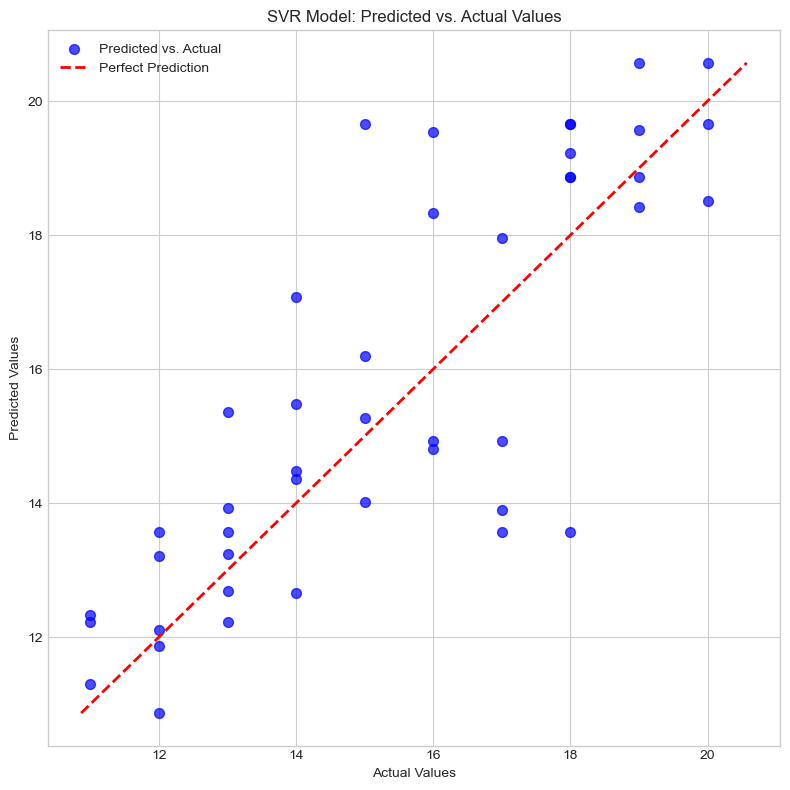

In [24]:
x_train = female[[18, 28, 38, 48]]
y_train = female["Completed Age"]
x_train = x_train.fillna(x_train.mean())
x_test = female_test[[18, 28, 38, 48]]
y_test = female_test["Completed Age"]
# svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)
svr_model = SVR()
param_grid = {
'kernel': ['rbf', 'linear', 'poly'],
'C': [0.1, 1, 10, 100],
'epsilon': [0.01, 0.1, 1]
}
grid_search = GridSearchCV(svr_model, param_grid, cv=5, scoring='r2')
grid_search.fit(x_train, y_train)
best_svr_model = grid_search.best_estimator_
best_params = grid_search.best_params_
print("Best Parameters found by GridSearchCV:")
print(best_params)
y_pred = best_svr_model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("SVR Model Evaluation Metrics:")
print("-" * 30)
print(f"Mean Squared Error (MSE): {mse:.5f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.5f}")
print(f"R-squared ($R^2$): {r2:.5f}")
plot_results(y_test, y_pred)